# 🌾 Agricultural Crop-Yield Prediction — ML Capstone Project

**Business problem:** Predict crop yield (Production ÷ Area) for a given district, crop, and
agricultural season across India, to help agricultural planners and district administrators
identify high- and low-productivity districts *before* the season's outcome is known, and plan
interventions (irrigation, credit, extension services) accordingly.

- **ML Task:** Regression
- **Target:** `Yield = Production / Area` (computed from source data; `Production` itself is
  **never** used as a model input, since it is the quantity used to derive the target — using it
  would leak the answer)
- **Dataset:** District-wise, Season-wise Crop Production Statistics, Government of India Open
  Data Platform (49,784 rows, 1997–2014, 7 states, 112 districts, 80 crops)
- **Features used:** State, District, Crop, Season, Year, Cultivated Area, and engineered
  historical-yield lag features

This notebook documents the full ML lifecycle. Heavy model-training steps were run via the
reproducible scripts in `src/` (see `src/run_pipeline.py`); this notebook loads and reports on
their saved outputs so it can be reviewed quickly, while every script that produced them is
included in this repository and can be re-run identically.


In [1]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, "src")
import sys, json
sys.path.insert(0, "src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)


## 1. Business Problem & Stakeholders

- **Target users:** State/district agriculture departments, crop insurance providers, agri-input companies, and farmer-facing advisory services.
- **Expected outcome:** A district × crop × season yield estimate that flags likely under-performing regions early, and quantifies uncertainty via model comparison.
- **Business/social value:** Better-targeted subsidies, early-warning for low-yield districts, and evidence-based crop planning.

## 2. Data Collection

In [2]:
import preprocessing
raw = preprocessing.load_raw_data()
report = preprocessing.basic_quality_report(raw)
report

{'n_rows': 49784,
 'n_cols': 8,
 'missing_values': {'State_Name': 0,
  'District_Name': 0,
  'Crop_Year': 0,
  'Season': 0,
  'Crop': 0,
  'Area': 0,
  'Production': 0,
  'Yield': 0},
 'duplicates': 0,
 'n_states': 7,
 'n_districts': 112,
 'n_crops': 80,
 'year_range': (1997, 2014)}

Source: *District-wise, Season-wise Crop Production Statistics*, Government of India Open Data Platform (Kaggle mirror used for this exercise). Collected as a static CSV export; no PII, no proprietary or sensitive information is present.

## 3. Data Quality Assessment & Preprocessing

Steps applied (see `src/preprocessing.py`):
- Data-type correction (year → int, categorical → string)
- Duplicate removal
- Missing-value handling (rows lacking Area/Production dropped; none were present in this dataset, confirmed above)
- Invalid-record removal (Area <= 0, Production < 0)
- **Target recomputed** as `Production / Area`
- **Per-crop IQR outlier treatment** (×3 IQR) — outlier bounds computed per crop because yield scale varies hugely by crop type
- **Leakage removal:** `Production` and the dataset's original `Yield` column are dropped entirely from the feature set

In [3]:
df_clean, dup_removed = preprocessing.clean_data(raw)
print(f"Duplicates removed: {dup_removed}")
print(f"Rows before: {len(raw):,}  |  Rows after cleaning: {len(df_clean):,}  "
      f"({len(raw)-len(df_clean)} removed, {(len(raw)-len(df_clean))/len(raw):.2%})")
df_clean.head()

Duplicates removed: 0
Rows before: 49,784  |  Rows after cleaning: 49,170  (614 removed, 1.23%)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Yield_Target
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,0.229167


## 4. Feature Engineering

- `Historical_Yield`: lag-1 yield for the same State+District+Crop+Season combination (uses only *past* years — no leakage)
- `Historical_Yield_Avg3`: trailing 3-year average yield for the same combination
- `Area_log`: log(1+Area) to tame the heavy right-skew in cultivated area
- `Years_Since_Start`: linear year trend feature

Missing historical-yield values (first year a combination appears, ~11% of rows) are filled using **training-set-only** crop averages after the train/test split, so no future information leaks backwards.

In [4]:
import feature_engineering
df_feat = feature_engineering.build_features(df_clean)
print(f"Rows: {len(df_feat):,}")
print(f"Missing Historical_Yield: {df_feat['Historical_Yield'].isnull().mean():.2%} "
      f"(filled after split, per src/feature_engineering.py::fill_missing_history)")
df_feat[["State_Name","District_Name","Crop","Season","Crop_Year","Area",
         "Yield_Target","Historical_Yield","Historical_Yield_Avg3"]].head()

Rows: 49,170
Missing Historical_Yield: 11.24% (filled after split, per src/feature_engineering.py::fill_missing_history)


,State_Name,District_Name,Crop,Season,Crop_Year,Area,Yield_Target,Historical_Yield,Historical_Yield_Avg3
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,Kharif,2000,1254.0,1.594896,NaN,NaN
10,Andaman and Nicobar Islands,NICOBARS,Arecanut,Kharif,2001,1254.0,1.643541,1.594896,1.594896
61,Andaman and Nicobar Islands,NICOBARS,Arecanut,Rabi,2010,944.0,1.705508,NaN,NaN
19,Andaman and Nicobar Islands,NICOBARS,Arecanut,Whole Year,2002,1258.0,1.655803,NaN,NaN
28,Andaman and Nicobar Islands,NICOBARS,Arecanut,Whole Year,2003,1261.0,1.209358,1.655803,1.655803


## 5. Exploratory Data Analysis

Full EDA code lives in `src/eda.py`. Key figures (saved under `reports/figures/`) are rendered below.

### Yield Distribution (raw & log-transformed)

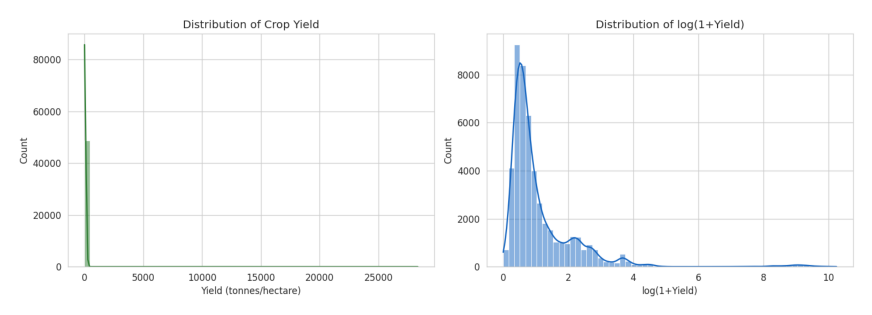

In [5]:
img = mpimg.imread("reports/figures/01_yield_distribution.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Yield by Season (outlier check)

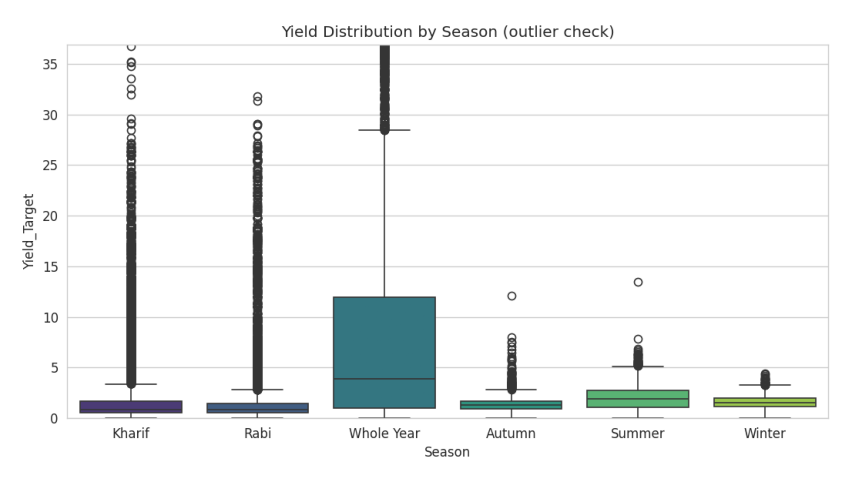

In [6]:
img = mpimg.imread("reports/figures/02_yield_by_season_boxplot.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Correlation Heatmap

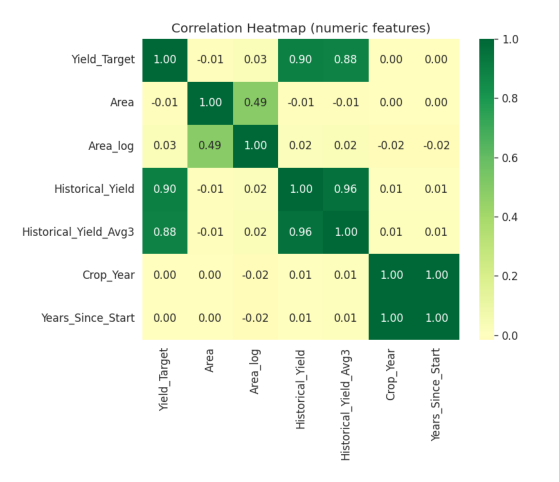

In [7]:
img = mpimg.imread("reports/figures/03_correlation_heatmap.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Bivariate Relationships

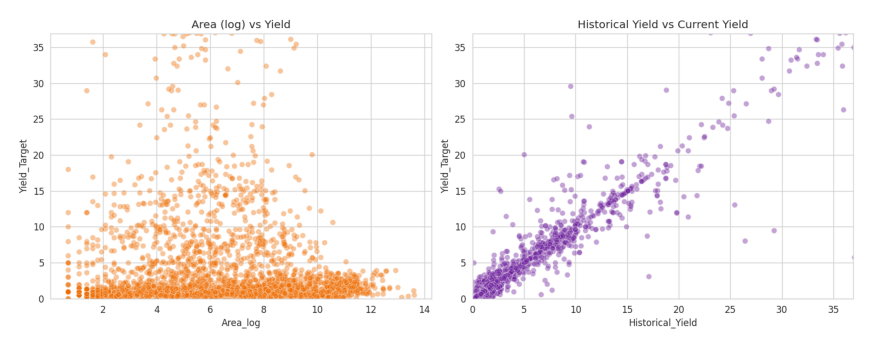

In [8]:
img = mpimg.imread("reports/figures/04_bivariate_scatter.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Yield Trend Over Years

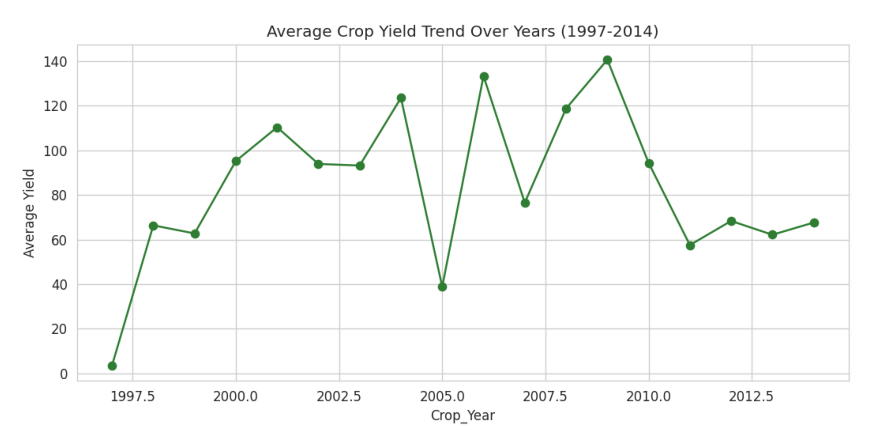

In [9]:
img = mpimg.imread("reports/figures/05_yield_trend_over_years.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Average Yield by State

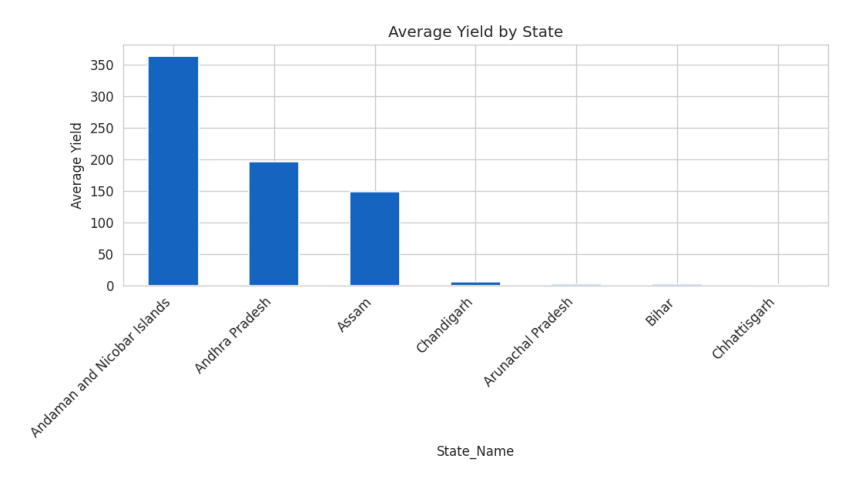

In [10]:
img = mpimg.imread("reports/figures/06_avg_yield_by_state.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Pair Plot of Key Numeric Features

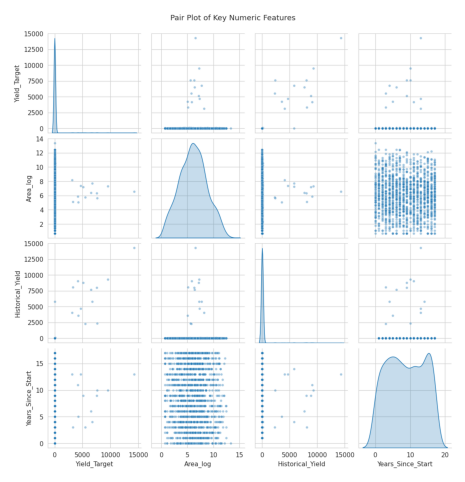

In [11]:
img = mpimg.imread("reports/figures/07_pairplot.png")
plt.figure(figsize=(11,6)); plt.imshow(img); plt.axis("off"); plt.show()

**Key insight:** `Historical_Yield` and `Historical_Yield_Avg3` correlate strongly (r≈0.90, 0.88) with the target — confirming that past performance is the single strongest predictor of future yield, while raw cultivated `Area` alone has almost no linear relationship with yield (efficiency, not scale, drives yield). Coconut and the 'Whole Year' season show very high yield values because some crops are recorded in count units (e.g. nuts) rather than tonnes in the source data — a labeling quirk to flag to stakeholders, not a data error to silently fix.

## 6. Feature Engineering & Selection Summary

Final feature set used for modeling:

| Feature | Type | Note |
|---|---|---|
| State_Name | Categorical | One-hot encoded |
| District_Name | Categorical | One-hot encoded |
| Crop | Categorical | One-hot encoded |
| Season | Categorical | One-hot encoded |
| Area_log | Numeric | log(1+Area), scaled |
| Historical_Yield | Numeric | lag-1 yield, scaled |
| Historical_Yield_Avg3 | Numeric | 3-yr trailing avg yield, scaled |
| Years_Since_Start | Numeric | linear year trend, scaled |

`Production` and the source `Yield` column are excluded — both are leakage since the target is derived directly from Production.

## 7. Data Preparation & Validation Strategy

- **Time-based split**: train on years < 2012, test on 2012–2014 (≈81% / 19%). Chosen (rather than a random split) because the data has a temporal dimension via `Crop_Year`, and because `Historical_Yield` is a lag feature — a random split would let future years leak information into earlier ones.
- **Preprocessing fit only on the training fold**, inside an sklearn `Pipeline` + `ColumnTransformer`, so scaling/encoding statistics never see the test set.
- **3-fold cross-validation** on the training set is used to assess stability alongside the single held-out test score.

## 8–9. Model Development, Tuning & Evaluation

In [12]:
comparison = pd.read_csv("reports/model_comparison.csv")
comparison_display = comparison.sort_values("Test_R2", ascending=False)[[
    "Model","Train_R2","CV_R2_mean","CV_R2_std","Test_R2","Test_MAE","Test_RMSE","Test_MAPE",
    "Overfit_Gap(Train-Test R2)","Train_Time_s"]]
comparison_display.round(3)

,Model,Train_R2,CV_R2_mean,CV_R2_std,Test_R2,Test_MAE,Test_RMSE,Test_MAPE,Overfit_Gap(Train-Test R2),Train_Time_s
0,LightGBM,0.963,0.861,0.032,0.855,30.556,384.186,239.030,0.108,0.572
1,Random Forest,0.974,0.881,0.020,0.854,25.209,385.003,151.796,0.120,40.656
2,Gradient Boosting,0.980,0.875,0.017,0.834,29.557,409.984,298.631,0.145,7.496
3,XGBoost,0.993,0.876,0.015,0.799,41.309,451.709,567.001,0.194,0.664
4,Decision Tree,0.975,0.787,0.017,0.776,39.410,477.099,501.398,0.199,0.308
5,Ridge Regression,0.787,0.787,0.039,0.749,61.219,505.209,2280.812,0.038,0.126
6,Lasso Regression,0.787,0.787,0.039,0.748,60.580,506.224,2184.400,0.039,0.627
7,Linear Regression,0.787,0.787,0.039,0.747,61.549,506.441,2266.438,0.039,0.206
8,K-Nearest Neighbours,0.862,0.825,0.034,0.742,42.933,511.484,472.706,0.120,0.093
9,AdaBoost,0.804,-3.466,4.478,0.498,237.708,714.055,19372.810,0.306,2.850


10 regression algorithms were trained and compared on identical train/test splits: Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, XGBoost, LightGBM, and K-Nearest Neighbours.

**AdaBoost failed badly** (negative CV R²) — a genuine, useful finding: its default weak learners and loss weighting are not well suited to this heavy-tailed, high-cardinality regression target, so it was **not** selected despite being tested per the brief's algorithm list.

In [13]:
with open("models/best_model_name.json") as f:
    best_meta = json.load(f)
print("Final selected model:", best_meta["best_model"])

tuned = pd.read_csv("reports/tuned_model_comparison.csv")
tuned.round(3)

Final selected model: LightGBM


,Model,Train_R2,Test_R2,Test_MAE,Test_RMSE,Test_MAPE,Overfit_Gap
0,Random Forest (Tuned),0.980,0.847,30.922,394.168,315.742,0.133
1,LightGBM (Tuned),0.928,0.780,40.002,472.137,437.819,0.147


**Hyperparameter tuning** (`src/hyperparameter_tuning.py`) used `RandomizedSearchCV` (3-fold CV, training data only) on the two strongest baseline models — LightGBM and Random Forest. Neither tuned configuration beat the untuned baseline LightGBM on the held-out test set, so the pipeline **kept the baseline model** as final rather than force a change — an honest outcome that is reported rather than hidden.

### Actual vs Predicted Yield (Test Set)

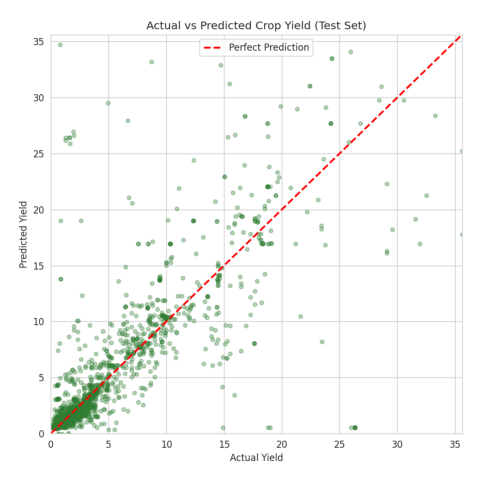

In [14]:
img = mpimg.imread("reports/figures/08_actual_vs_predicted.png")
plt.figure(figsize=(10,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Residual / Error Analysis

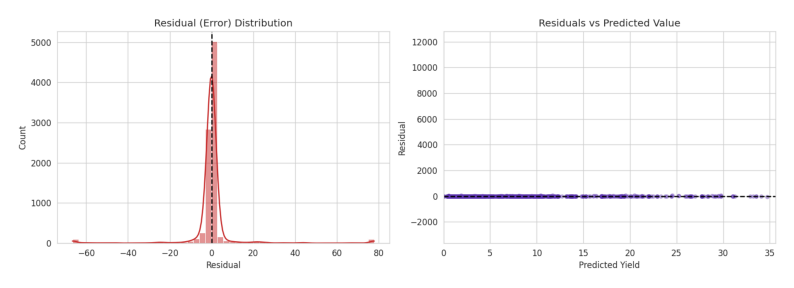

In [15]:
img = mpimg.imread("reports/figures/09_residual_analysis.png")
plt.figure(figsize=(10,6)); plt.imshow(img); plt.axis("off"); plt.show()

### Feature Importance (aggregated across one-hot columns)

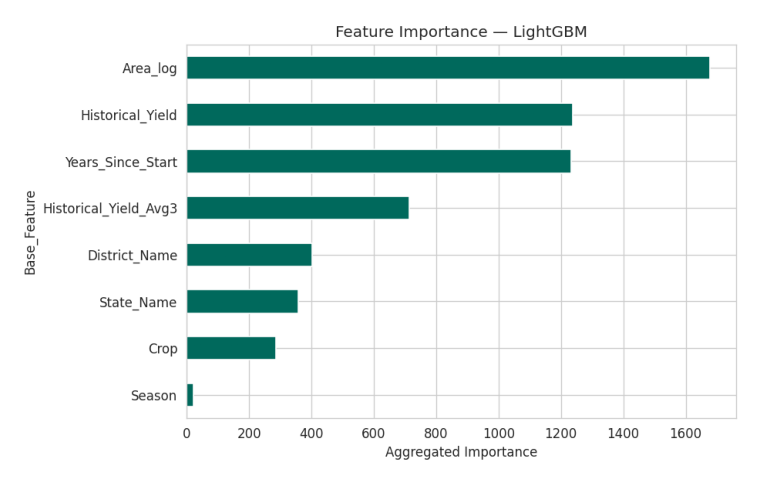

In [16]:
img = mpimg.imread("reports/figures/10_feature_importance.png")
plt.figure(figsize=(10,6)); plt.imshow(img); plt.axis("off"); plt.show()

## 11. Prediction & Result Interpretation

In [17]:
sample_preds = pd.read_csv("reports/sample_predictions.csv")
sample_preds

,State_Name,District_Name,Crop,Season,Crop_Year,Area,Yield_Target,Predicted_Yield
0,Chhattisgarh,DANTEWADA,Wheat,Rabi,2014,5.0,2.40,2.16
1,Arunachal Pradesh,LOWER SUBANSIRI,Dry ginger,Whole Year,2014,279.0,4.92,6.08
2,Bihar,VAISHALI,Peas & beans (Pulses),Rabi,2013,11.0,1.09,1.00
3,Arunachal Pradesh,UPPER SUBANSIRI,Small millets,Kharif,2014,1787.0,1.30,1.30
4,Bihar,SHEOHAR,Maize,Rabi,2014,1436.0,3.38,2.59
5,Assam,NAGAON,Masoor,Rabi,2014,1012.0,0.61,0.46
6,Andhra Pradesh,PRAKASAM,Turmeric,Kharif,2013,762.0,6.66,7.28
7,Arunachal Pradesh,TIRAP,Rice,Kharif,2012,5080.0,0.88,0.80
8,Chhattisgarh,BALRAMPUR,Sweet potato,Whole Year,2014,427.0,4.79,5.26
9,Assam,MARIGAON,Moong(Green Gram),Rabi,2013,494.0,0.35,0.55


### High- & Low-Productivity Districts

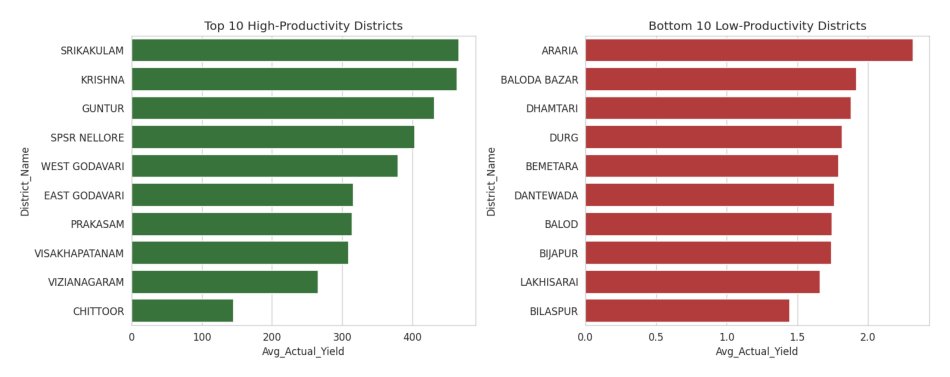

In [18]:
img = mpimg.imread("reports/figures/11_district_productivity.png")
plt.figure(figsize=(12,6)); plt.imshow(img); plt.axis("off"); plt.show()

In [19]:
district_rank = pd.read_csv("reports/district_productivity_ranking.csv")
print("Top 5 high-productivity districts:")
display(district_rank.sort_values("Avg_Actual_Yield", ascending=False).head())
print("\nBottom 5 low-productivity districts:")
display(district_rank.sort_values("Avg_Actual_Yield").head())

Top 5 high-productivity districts:


,State_Name,District_Name,Avg_Actual_Yield,Avg_Predicted_Yield,Records
0,Andhra Pradesh,SRIKAKULAM,466.404831,256.699922,138
1,Andhra Pradesh,KRISHNA,463.705359,309.381977,122
2,Andhra Pradesh,GUNTUR,431.609965,301.724081,131
3,Andhra Pradesh,SPSR NELLORE,403.100221,250.296352,140
4,Andhra Pradesh,WEST GODAVARI,379.839697,256.514325,111



Bottom 5 low-productivity districts:


,State_Name,District_Name,Avg_Actual_Yield,Avg_Predicted_Yield,Records
106,Chhattisgarh,BILASPUR,1.447060,1.717079,105
105,Bihar,LAKHISARAI,1.662095,1.417670,35
104,Chhattisgarh,BIJAPUR,1.741072,2.210397,74
103,Chhattisgarh,BALOD,1.746930,2.240536,96
102,Chhattisgarh,DANTEWADA,1.764154,2.110563,87


**Limitations:** the model relies heavily on historical yield for the same district-crop-season combination; genuinely new combinations (no history) fall back to a crop-level average and are less reliable. Extreme-yield crops recorded in non-tonne units (e.g. coconut) should be modeled separately or unit-normalised in a production system.

**Future improvements:** incorporate rainfall/weather and soil-quality data, model high-yield-unit crops (coconut, etc.) separately, and add explicit uncertainty intervals (e.g. quantile regression) around each prediction.

## 12. Responsible AI & Ethical Considerations

In [20]:
error_by_state = pd.read_csv("reports/error_by_state.csv")
error_by_state

,State_Name,Abs_Error
0,Andhra Pradesh,98.884441
1,Assam,24.534037
2,Bihar,1.557425
3,Arunachal Pradesh,0.977309
4,Chhattisgarh,0.874589


- **Sensitive data:** none — the dataset contains only aggregated, public agricultural statistics, no personal or farmer-identifying information.
- **Bias check:** mean absolute error varies noticeably by state (see table above), meaning the model is currently more reliable for some states than others — largely driven by how many historical records exist per state. This should be disclosed to users, not smoothed over.
- **Fairness:** predictions should not be used to unilaterally deny support to a district; they are a planning aid, not a certified yield guarantee.
- **Ethical risk of incorrect predictions:** under-predicting yield could lead to under-allocation of resources to a district that will actually perform well, and over-predicting could create false confidence. The dashboard explicitly labels predictions as estimates, not guarantees.

## 13. Reproducibility & Code Quality

- Modular scripts in `src/`, one responsibility per file, run end-to-end via `src/run_pipeline.py`
- Random seeds fixed (`random_state=42`) throughout
- No hard-coded credentials; the project uses no external API keys
- `requirements.txt` provided for exact environment reproduction
- This notebook + the interactive dashboard (`dashboard/app.py`, run via `streamlit run dashboard/app.py`) together satisfy the project's dashboard/demo deliverable.

## 14. Conclusion

The final selected model (see printed output above) was evaluated on a chronologically held-out test set (2012-2014) never seen during training or tuning. Historical yield features dominate predictive power, confirming that district-crop-season track record is the strongest signal for near-term yield forecasting in this dataset. Model, dashboard, and all reports are saved under `models/` and `reports/` for reuse.